=== Régression Linéaire Simple ===
Theta: [-82.          42.69090909]

=== Régression Linéaire Multiple ===
Theta: [-68.   45.6  -6. ]

=== Régression Polynomiale ===
Theta: [ 39.33333333 -17.97575758   5.51515152]

=== Régression Logistique ===
Theta: [-0.34075344  0.60748529 -0.50983838]
Probabilités: [0.22049514 0.34179664 0.36409113 0.51245597 0.53680359 0.68025989
 0.70111506 0.81154776 0.82602961 0.89708349]
Prédictions: [0 0 0 1 1 1 1 1 1 1]


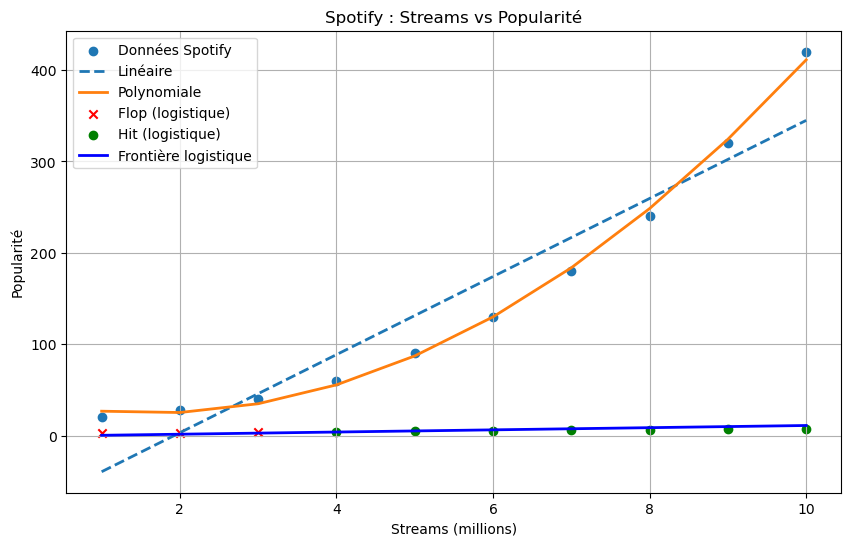

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# 1. DATASET SPOTIFY
# =====================================================
# X_simple : représente la variable explicative (input) dans une régression linéaire simple ici c'est le nombre de streams (en millions)
X_simple = np.array([1,2,3,4,5,6,7,8,9,10])

# # X_multiple : matrice des variables explicatives
# x1 = streams, x2 = durée du morceau (minutes)
X_multiple = np.array([
    [1,3], [2,3], [3,4], [4,4], [5,5],
    [6,5], [7,6], [8,6], [9,7], [10,7]
])
# y : variable cible (output)
#ici représente la popularité du morceau 

y = np.array([20, 28, 40, 60, 90, 130, 180, 240, 320, 420])

# =====================================================
# 2. FONCTION GÉNÉRALE : ÉQUATION NORMALE
# =====================================================
def linear_regression(X, y):
    
    # -----------------------------------------------------
    # Étape 1 : Ajout du biais (intercept)
    # -----------------------------------------------------
    # Modèle mathématique :
    # y = θ0 + θ1*x1 + θ2*x2 + ... + θn*xn
    #
    # Pour écrire ce modèle sous forme matricielle :
    # y = Xθ
    #
    # On ajoute une colonne de 1 à X pour intégrer θ0 :
    #
    # X_b = [1  x1  x2 ... xn]
    #
    X_b = np.c_[np.ones((len(X),1)), X]
    
    
    # -----------------------------------------------------
    # Étape 2 : Calcul de θ avec l'équation normale
    # -----------------------------------------------------
    # Objectif :
    # Minimiser la fonction de coût (moindres carrés) :
    #
    # J(θ) = Σ (y_i - ŷ_i)^2 = ||y - Xθ||^2
    #
    # En dérivant J(θ) et en posant ∇J(θ) = 0,
    # on obtient la solution analytique :
    #
    # θ = (Xᵀ X)^(-1) Xᵀ y
    #
    
    # X_b.T        → Xᵀ (transposée de la matrice X)
    # X_b.T.dot(X_b) → Xᵀ X (produit matriciel)
    # np.linalg.inv → (Xᵀ X)^(-1) (inverse de la matrice)
    # .dot(y)       → multiplication finale avec y
    #
    theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    
    
    # -----------------------------------------------------
    # Résultat :
    # -----------------------------------------------------
    # θ = [θ0, θ1, θ2, ..., θn]
    #
    # θ0 : biais (valeur de y quand X = 0)
    # θi : influence de la variable xi sur y
    #
    return theta

# =====================================================
# 3. RÉGRESSION LINÉAIRE SIMPLE
# Modèle mathématique :
# y = θ0 + θ1 x
#
# Interprétation :
# θ0 : biais (valeur de y quand x = 0)
# θ1 : pente (influence de x sur y)
theta_simple = linear_regression(X_simple.reshape(-1,1), y)


# Calcul des prédictions :
# ŷ = θ0 + θ1 * x
# (application directe du modèle sur les données)
y_pred_simple = theta_simple[0] + theta_simple[1]*X_simple

print("=== Régression Linéaire Simple ===")
print("Theta:", theta_simple)
print()

# =====================================================
# 4. RÉGRESSION LINÉAIRE MULTIPLE
# Modèle mathématique :
# y = θ0 + θ1 x1 + θ2 x2
#
# Interprétation :
# x1 = streams
# x2 = durée
#
# Chaque variable a son propre poids (coefficient
# =====================================================
theta_multiple = linear_regression(X_multiple, y)

print("=== Régression Linéaire Multiple ===")
print("Theta:", theta_multiple)
print()

# =====================================================
# 5. RÉGRESSION POLYNOMIALE (degré 2)
## Idée clé :
# Transformer une relation non-linéaire en problème linéaire
#
# Modèle mathématique :
# y = θ0 + θ1 x + θ2 x²
#
# On crée une nouvelle variable :
# x² (feature engineering)
# =====================================================
X_poly = np.c_[X_simple, X_simple**2]

theta_poly = linear_regression(X_poly, y)
# Prédiction :
y_pred_poly = (theta_poly[0] +
               theta_poly[1]*X_simple +
               theta_poly[2]*(X_simple**2))

print("=== Régression Polynomiale ===")
print("Theta:", theta_poly)
print()
# =====================================================
# 6. RÉGRESSION LOGISTIQUE (Spotify Hit / Flop)
# =====================================================

# Transformation de y en classification :
# on considère populaire (1) si y > 100 sinon 0
y_log = (y > 100).astype(int)


# =====================================================
# Fonction sigmoïde
# =====================================================
# σ(z) = 1 / (1 + e^(-z))
# transforme une valeur réelle en probabilité

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# =====================================================
# Gradient Descent Logistic Regression
# =====================================================
# Modèle :
# hθ(x) = σ(Xθ)
#
# Fonction de coût :
# J(θ) = - (1/m) Σ [y log(h) + (1-y) log(1-h)]
#
# Gradient :
# ∇J(θ) = (1/m) Xᵀ (h - y)
#
# Mise à jour :
# θ = θ - α * gradient

def logistic_regression(X, y, lr=0.001, iterations=3000):

    m = len(y)

    # Ajout du biais
    X_b = np.c_[np.ones((m,1)), X]

    # initialisation θ
    theta = np.zeros(X_b.shape[1])

    for i in range(iterations):

        # z = Xθ
        z = X_b.dot(theta)

        # hθ(x)
        h = sigmoid(z)

        # gradient
        gradient = (1/m) * X_b.T.dot(h - y)

        # update
        theta = theta - lr * gradient

    return theta


# =====================================================
# ENTRAÎNEMENT
# =====================================================
theta_log = logistic_regression(X_multiple, y_log)

print("=== Régression Logistique ===")
print("Theta:", theta_log)


# =====================================================
# PRÉDICTION
# =====================================================
X_b = np.c_[np.ones((len(X_multiple),1)), X_multiple]

proba = sigmoid(X_b.dot(theta_log))

pred = (proba >= 0.5).astype(int)

print("Probabilités:", proba)
print("Prédictions:", pred)
# =====================================================
# 7. VISUALISATION (SIMPLE + POLYNOMIALE+LOGISTIQUE)
# =====================================================
plt.figure(figsize=(10,6))

plt.scatter(X_simple, y, label="Données Spotify")

plt.plot(X_simple, y_pred_simple, '--', linewidth=2,
         label="Linéaire")

plt.plot(X_simple, y_pred_poly, linewidth=2,
         label="Polynomiale")

plt.title("Spotify : Streams vs Popularité")
plt.xlabel("Streams (millions)")
plt.ylabel("Popularité")
plt.grid(True)
plt.legend()
# =====================================================
# VISUALISATION RÉGRESSION LOGISTIQUE
# =====================================================

# Ajout du biais
X_log = np.c_[np.ones((len(X_multiple),1)), X_multiple]

# Probabilités
proba_log = sigmoid(X_log.dot(theta_log))

# Classes prédites
y_log_pred = (proba_log >= 0.5).astype(int)

# Séparation des classes
flop = y_log_pred == 0
hit = y_log_pred == 1

# Nuage de points logistique
plt.scatter(X_multiple[flop][:,0], X_multiple[flop][:,1],
            color='red', marker='x', label='Flop (logistique)')

plt.scatter(X_multiple[hit][:,0], X_multiple[hit][:,1],
            color='green', marker='o', label='Hit (logistique)')


# =====================================================
# FRONTIÈRE DE DÉCISION
# =====================================================
x1 = np.linspace(min(X_multiple[:,0]), max(X_multiple[:,0]), 100)

if theta_log[2] != 0:
    x2 = -(theta_log[0] + theta_log[1]*x1) / theta_log[2]
    plt.plot(x1, x2, color='blue', linewidth=2,
             label='Frontière logistique')
plt.legend()
plt.show()